In [ ]:
import pandas as pd

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving titanic.csv to titanic (1).csv


In [ ]:
df=pd.read_csv("titanic (1).csv")

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.duplicated().value_counts()

,count
False,891


In [ ]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
#code for dropping duplicating value
df = df.drop_duplicates()

In [ ]:
df = df.drop(columns=['Cabin'])

In [ ]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [ ]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [ ]:
#rechecking duplicate values
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [ ]:
survival_counts = df['Survived'].value_counts()
print("Survival Counts:\n", survival_counts)

Survival Counts:
 Survived
0    549
1    342
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Encode Sex (Male=1, Female=0)
le = LabelEncoder()
df["Sex"] = le.fit_transform(df["Sex"])

In [ ]:
from sklearn.preprocessing import LabelEncoder
le_embarked = LabelEncoder()
df['Embarked'] = le_embarked.fit_transform(df['Embarked'])
X = df.drop(["Survived", "Sex", "Name", "Ticket", "PassengerId"], axis=1)
y = df["Survived"]

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
# Logistic Regression
log_reg = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
# Logistic Regression
y_pred_log = log_reg.predict(X_test)
print("\nLogistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log, target_names=["Not Survived","Survived"]))


Logistic Regression Results
Accuracy: 0.7164179104477612
              precision    recall  f1-score   support

Not Survived       0.70      0.90      0.79       157
    Survived       0.76      0.46      0.57       111

    accuracy                           0.72       268
   macro avg       0.73      0.68      0.68       268
weighted avg       0.73      0.72      0.70       268



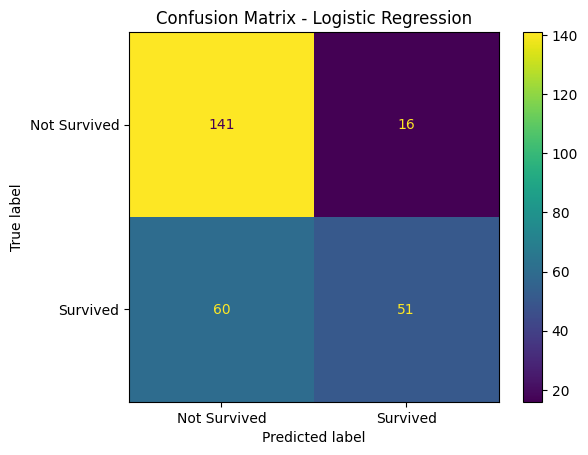

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_log)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Survived", "Survived"])
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [ ]:
#External Prediction
# ------------------------------
# The new_data should reflect the features remaining in X after dropping 'Survived', 'Sex', 'Name', 'Ticket', 'PassengerId'
# The remaining columns are: 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'
# Example: [Pclass, Age, SibSp, Parch, Fare, Embarked (encoded)]
new_data = [[3, 22.0, 1, 0, 7.25, 2]]  # Example new input for a male (3 is Pclass, 22.0 is Age, 1 is SibSp, 0 is Parch, 7.25 is Fare, 2 is Embarked (S))

# Column names must match training data
new_data_df = pd.DataFrame(new_data, columns=X.columns)

# Predict again
log_result = log_reg.predict(new_data_df)[0]

# Map 0 to 'Not Survived' and 1 to 'Survived'
prediction_label = "Survived" if log_result == 1 else "Not Survived"

print("Logistic Regression Prediction:", prediction_label)

Logistic Regression Prediction: Not Survived
